# Complementaria Semana 9: Cadenas de Markov en Python II


## Objetivos

Al finalizar la sesión, el estudiante podrá:

1. Obtener probabilidades marginales a partir de una distribución transitoria conjunta.
2. Calcular medidas de una función del estado, como la varianza del número total de pacientes.
3. Calcular probabilidades de eventos en estado estable.
4. Comparar la evolución transitoria de una probabilidad con su valor de estado estable.
5. Aplicar estas herramientas a preguntas de costo esperado, primera pasada y tiempo de ocupación.

## 1. Recordatorio del modelo 

Continuamos con el hospital de la sesión anterior: $B=20$ camas, dos tipos de pacientes y $b=5$ camas reservadas para tipo 1.

El estado es

$$
Z(t)=(X(t),Y(t)),
$$

donde $X(t)$ y $Y(t)$ representan el número de pacientes de cada tipo.

En la sesión anterior construimos la matriz generadora $Q$ y aprendimos a obtener distribuciones transitorias y de estado estable. Aquí nos concentraremos en **cómo extraer información útil de esas distribuciones**.

In [1]:
# Creacion de la cadena de markov para el hospital

import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# Definimos los parámetros
B = 20  # Número total de camas
b = 5   # Número de camas reservadas para pacientes tipo 1
lambda_1 = 6.5  # Tasa de llegada de pacientes tipo 1 (por hora)
lambda_2 = 3  # Tasa de llegada de pacientes tipo 2 (por hora)
mu_1 = 2      # Tasa de salida de pacientes tipo 1 (por hora)
mu_2 = 1.5    # Tasa de salida de pacientes tipo 2 (por hora)

# Dimensión de la matriz Q
num_estados = (B + 1) * (B - b + 1)

# Inicializamos la matriz Q con ceros
Q_evaluar = np.zeros((num_estados, num_estados), dtype=float)

# Función para mapear (i, j) a índice en la matriz Q
def index(i, j):
    return i * (B - b + 1) + j

# Llenar la matriz Q
for i in range(B + 1):
    for j in range(B - b + 1):
        idx = index(i, j)

        # Llegada de un paciente tipo 1
        if i < B:
            Q_evaluar[idx, index(i + 1, j)] = lambda_1

        # Llegada de un paciente tipo 2 (si hay espacio disponible)
        if j < B - b:
            Q_evaluar[idx, index(i, j + 1)] = lambda_2

        # Salida de un paciente tipo 1
        if i > 0:
            Q_evaluar[idx, index(i - 1, j)] = i * mu_1

        # Salida de un paciente tipo 2
        if j > 0:
            Q_evaluar[idx, index(i, j - 1)] = j * mu_2

# Llenar la diagonal con la suma negativa de las filas de la matriz
for i in range(num_estados):
    Q_evaluar[i, i] = -np.sum(Q_evaluar[i, :])
    
from jmarkov.ctmc import ctmc

# Crear la cadena de Markov en tiempo continuo usando jmarkov
hospital_chain = ctmc(Q_evaluar)

In [2]:
# Funciones auxiliares que usaremos en toda la sesión
def vector_a_matriz(pi_vec):
    # Convierte vector de probabilidades a matriz (i, j)
    M = np.zeros((B + 1, B - b + 1))
    for i in range(B + 1):
        for j in range(B - b + 1):
            M[i, j] = pi_vec[index(i, j)]
    return M

def plot_heatmap(pi_mat, titulo, ax, max_i=10, max_j=10):
    region = pi_mat[:max_i, :max_j]
    im = ax.imshow(region.T, origin='lower', aspect='auto', cmap='YlOrRd')
    ax.set_xlabel('Pacientes Tipo 1 (i)')
    ax.set_ylabel('Pacientes Tipo 2 (j)')
    ax.set_title(titulo)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(min(8, max_i)):
        for j in range(min(8, max_j)):
            val = region[i, j]
            if val > 0.004:
                ax.text(i, j, f'{val:.3f}', ha='center', va='center', fontsize=6,
                       color='white' if val > 0.02 else 'black')
    return im

## 2. De una distribución conjunta a una marginal 

Suponga que el hospital inicia en $(1,1)$ y queremos:

> ¿Cuál es la probabilidad de tener exactamente 4 pacientes tipo 2 después de 5 horas?

No se especifica cuántos pacientes tipo 1 hay. Por tanto, debemos sumar sobre todos los valores posibles de $X(5)$:

$$
P(Y(5)=4)=\sum_i P(X(5)=i,Y(5)=4).
$$

Esta es la idea de una **distribución marginal**.

In [3]:
# --------------------------------------------------------------------
# Pregunta 1: ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas?
# Partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.
alpha = np.zeros(num_estados)
alpha[index(1,1)] = 1

In [4]:
probs_transitorias_5h = hospital_chain.transient_probabilities(t=5, alpha=alpha)

In [17]:
# Calcular la distribución marginal de Y(5) para todos los valores de j
prob_marg_tipo2 = [sum(probs_transitorias_5h[index(i, j)]
                        for i in range(B + 1)) 
                        for j in range(B - b + 1)]


# Mostrar la probabilidad específica para j = 4
print(f"Probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas: {prob_marg_tipo2[4]:.6f}")

Probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas: 0.090174


### Visualización rápida

La marginal permite ver cómo se distribuye $Y(5)$ y ubicar la probabilidad de interés.

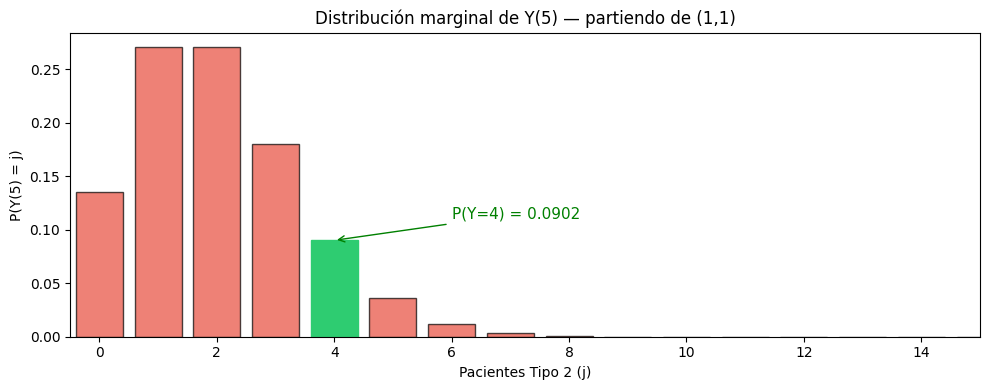

In [6]:
# Visualizar la marginal completa de Y
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(B - b + 1), prob_marg_tipo2, color='#e74c3c', edgecolor='black', alpha=0.7)
bars[4].set_color('#2ecc71')  # Resaltar j=4
bars[4].set_alpha(1.0)
ax.set_xlabel('Pacientes Tipo 2 (j)')
ax.set_ylabel('P(Y(5) = j)')
ax.set_title('Distribución marginal de Y(5) — partiendo de (1,1)')
ax.set_xlim(-0.5, B - b)
ax.annotate(f'P(Y=4) = {prob_marg_tipo2[4]:.4f}', xy=(4, prob_marg_tipo2[4]), xytext=(6, prob_marg_tipo2[4] + 0.02),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=11, color='green')
plt.tight_layout()
plt.show()

## 3. Funciones del estado: varianza 

Ahora definimos una nueva variable:

$$
T(t)=X(t)+Y(t),
$$

el número total de pacientes.

A partir de la distribución conjunta podemos calcular:

$$
E[T]=\sum_{i,j}(i+j)P(X=i,Y=j)
$$

y

$$
Var(T)=E[T^2]-E[T]^2.
$$

La idea importante es que **no necesitamos construir una nueva CMTC para estudiar $T$**: podemos obtener sus medidas directamente a partir de la distribución de $(X,Y)$.

In [7]:
# --------------------------------------------------------------------
# Pregunta 2: Calcule la varianza del número total de pacientes en el hospital tras 2 horas y 6 horas,
# dado que al inicio está vacío. Compare los resultados obtenidos.

# vector de estados inciales para hospital vacio (0, 0)
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1

# Probabilidades transitorias en 2 horas
probs_transitorias_2h = hospital_chain.transient_probabilities(t=2, alpha=alpha)

# Probabilidades transitorias en 6 horas
probs_transitorias_6h = hospital_chain.transient_probabilities(t=6, alpha=alpha)

In [8]:
# Función para calcular varianza dada una distribución de probabilidad
def calcular_varianza(probs):
    esperanza = sum((i + j) * probs[index(i, j)]
                    for i in range(B + 1)
                    for j in range(B - b + 1))
    
    esperanza_cuadrado = sum(probs[index(i, j)] * (i + j) ** 2
                             for i in range(B + 1)
                             for j in range(B - b + 1))
    varianza = esperanza_cuadrado - esperanza ** 2
    return varianza

In [9]:
# Cálculo de varianza en los distintos momentos

varianza_2h = calcular_varianza(probs_transitorias_2h)
varianza_6h = calcular_varianza(probs_transitorias_6h)

# Mostrar resultados
print(f"Varianza del número de pacientes tras 2 horas: {varianza_2h:.3f}")
print(f"Varianza del número de pacientes tras 6 horas: {varianza_6h:.3f}")

Varianza del número de pacientes tras 2 horas: 5.091
Varianza del número de pacientes tras 6 horas: 5.250


## 4. Estado estable vs. comportamiento transitorio 

En estado estable, la distribución satisface

$$
\pi Q=0,
\qquad
\sum_{i,j}\pi_{(i,j)}=1.
$$

Por ejemplo, podemos preguntar:

$$
P(X>Y)
=
\sum_{i>j}\pi_{(i,j)}.
$$

Después podemos comparar ese valor con

$$
P(X(t)>Y(t))
$$

a lo largo del tiempo.

Esta comparación permite visualizar la diferencia entre **transitorio** y **largo plazo**.

In [10]:
# --------------------------------------------------------------------
# Pregunta 3: Calcule la probabilidad de que haya más pacientes tipo 1 que tipo 2 a largo plazo.

# Calcular la distribución en estado estable
pi_estable = hospital_chain.steady_state()

# Sumar las probabilidades donde i > j en estado estable
prob_mas_1_estable = sum(pi_estable[index(i, j)]
                         for i in range(B + 1)
                         for j in range(B - b + 1)
                         if i > j)

print(f"Probabilidad de que haya más pacientes tipo 1 que tipo 2 en estado estable: {prob_mas_1_estable:.6f}")

Probabilidad de que haya más pacientes tipo 1 que tipo 2 en estado estable: 0.625781


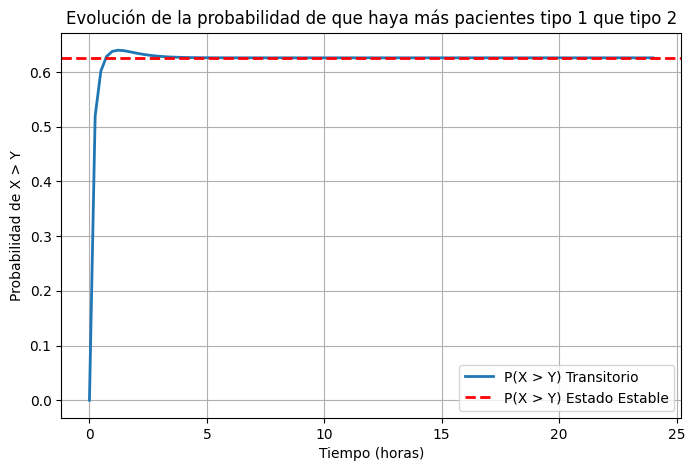

In [11]:
# --------------------------------------------------------------------
### Pregunta 4: Genere una gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2
#  en función del tiempo, desde 0 hasta 24 horas. Compare con el valor obtenido en el punto anterior.

# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Estado inicial: hospital vacío
alpha_vacio = np.zeros(num_estados)
alpha_vacio[index(0, 0)] = 1

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha_vacio)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)


# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y) Transitorio", linewidth=2)

# Añadir una línea horizontal roja para el estado estable
plt.axhline(y=prob_mas_1_estable, color='r', linestyle='--', label="P(X > Y) Estado Estable", linewidth=2)

plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

### Cierre de la complementaria

Hasta aquí hemos visto tres operaciones fundamentales:

1. **Marginalizar** una distribución conjunta.
2. Calcular medidas de una **función del estado**.
3. Calcular la probabilidad de un **evento en estado estable** y compararla con su evolución transitoria.

El resto de la sesión se dedica a aplicar estas ideas en preguntas que requieren mayor elaboración.

Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co